# 05 · Tools：先跑通一次可观察的工具调用

这一节暂时不做意图分流，只验证最小工具闭环：

HumanMessage → Agent → AIMessage(tool call) → ToolNode → ToolMessage → Agent → final

练习使用 TEU 换算作为确定性工具。只有最终数字不算通关，必须看到工具名、参数、调用 ID 和 ToolMessage。


In [1]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Annotated, TypedDict, Literal

from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists() and (candidate / ".env.example").exists():
        ROOT = candidate
        break
os.chdir(ROOT)
load_dotenv(ROOT / ".env")

LIVE_MODEL_CONFIGURED = bool((os.getenv("LLM_BASE_URL") or "").strip() and (os.getenv("LLM_MODEL") or "").strip())
print("cwd =", ROOT)
print("live_model_configured =", LIVE_MODEL_CONFIGURED)


cwd = /Users/kunwei/Projects/oocl-agent-workshop-lab/oocl-2026-ai-agent-training
live_model_configured = True


## 1. 先把工具当普通函数验收


In [2]:
TEU_PER_EQUIPMENT = {"20GP": 1, "40GP": 2, "40HQ": 2}


@tool
def calculate_teu(equipment: str, quantity: int) -> int:
    """按课堂约定换算 TEU。支持 20GP、40GP、40HQ。"""
    key = equipment.strip().upper()
    if key not in TEU_PER_EQUIPMENT:
        raise ValueError(f"不支持的箱型: {equipment}")
    if quantity < 0:
        raise ValueError("quantity 不能为负数")
    return TEU_PER_EQUIPMENT[key] * quantity


assert calculate_teu.invoke({"equipment": "40HQ", "quantity": 3}) == 6
assert calculate_teu.invoke({"equipment": "20GP", "quantity": 2}) == 2
print("05 tool unit ok: 3×40HQ=6, 2×20GP=2")


05 tool unit ok: 3×40HQ=6, 2×20GP=2


## 2. 把工具接进 LangGraph

Agent 节点只负责提出工具调用或生成最终回答；ToolNode 才负责校验参数、执行函数并把 ToolMessage 追加到 messages。


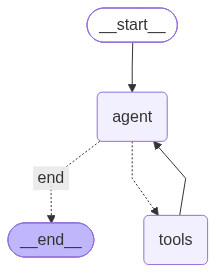

In [3]:
class ToolState(TypedDict):
    messages: Annotated[list, add_messages]


def make_llm():
    from langchain_openai import ChatOpenAI

    return ChatOpenAI(
        model=os.environ["LLM_MODEL"],
        api_key=os.getenv("LLM_API_KEY") or "not-required",
        base_url=os.environ["LLM_BASE_URL"],
        temperature=0,
    )


llm_with_tools = make_llm().bind_tools([calculate_teu]) if LIVE_MODEL_CONFIGURED else None


def agent(state: ToolState) -> dict:
    if llm_with_tools is None:
        raise RuntimeError("blocked_external_model: 请配置 LLM_BASE_URL 与 LLM_MODEL")
    response = llm_with_tools.invoke([
        SystemMessage(content="所有 TEU 计算必须调用 calculate_teu；收到工具结果后再汇总。"),
        *state["messages"],
    ])
    return {"messages": [response]}


def after_agent(state: ToolState) -> Literal["tools", END]:
    return "tools" if getattr(state["messages"][-1], "tool_calls", None) else END


builder = StateGraph(ToolState)
builder.add_node("agent", agent)
builder.add_node("tools", ToolNode([calculate_teu]))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", after_agent, {"tools": "tools", "end": END})
builder.add_edge("tools", "agent")
graph = builder.compile()

try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:
    print("PNG 不可用，打印 Mermaid：", exc)
    print(graph.get_graph().draw_mermaid())


## 3. 运行真实工具闭环


In [ ]:
if LIVE_MODEL_CONFIGURED:
    result = graph.invoke({
        "messages": [HumanMessage(content="请用工具计算 3×40HQ + 2×20GP 的 TEU，并汇总。")]
    })
    tool_messages = [message for message in result["messages"] if isinstance(message, ToolMessage)]
    print("message_types =", [type(message).__name__ for message in result["messages"]])
    print("tool_messages =", [(message.name, message.tool_call_id, message.content) for message in tool_messages])
    assert len(tool_messages) == 2
    assert all(message.name == "calculate_teu" for message in tool_messages)
    assert sum(int(str(message.content)) for message in tool_messages) == 8
    print("05 tools live path ok")
else:
    print("05 deterministic preflight ok; live path = blocked_external_model")


## 20 分钟双人练习

使用自己的 AI Coding 工具完成：

1. 新增一个只读工具，输入和返回值必须有明确 schema。
2. 把它接入 StateGraph 的 Agent ↔ ToolNode 循环。
3. 保存一条 AIMessage(tool call) 与对应 ToolMessage。
4. 准备一个非法参数失败样例；失败不得伪装成成功回答。

交付：图结构、一次成功 Trace、一次失败证据。20 分钟后随机抽一组展示。
